In [1]:
import pandas as pd
import numpy as np

file_path = "breast-cancer-dataset.csv"
df = pd.read_csv(file_path)

df.head()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History
0,1,2019,40,1,2,0,Right,0,Upper inner,0
1,2,2019,39,1,2,0,Left,0,Upper outer,0
2,3,2019,45,0,4,0,Left,0,Lower outer,0
3,4,2019,26,1,3,0,Left,0,Lower inner,1
4,5,2019,21,1,1,0,Right,0,Upper outer,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   S/N              213 non-null    int64
 1   Year             213 non-null    str  
 2   Age              213 non-null    int64
 3   Menopause        213 non-null    int64
 4   Tumor Size (cm)  213 non-null    str  
 5   Inv-Nodes        213 non-null    str  
 6   Breast           213 non-null    str  
 7   Metastasis       213 non-null    str  
 8   Breast Quadrant  213 non-null    str  
 9   History          213 non-null    str  
dtypes: int64(3), str(7)
memory usage: 16.8 KB


In [3]:
df.describe()

,S/N,Age,Menopause
count,213.000000,213.000000,213.000000
mean,107.000000,39.784038,0.666667
std,61.631972,14.096712,0.472515
min,1.000000,13.000000,0.000000
25%,54.000000,30.000000,0.000000
50%,107.000000,40.000000,1.000000
75%,160.000000,49.000000,1.000000
max,213.000000,77.000000,1.000000


In [4]:
df.columns

Index(['S/N', 'Year', 'Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes',
       'Breast', 'Metastasis', 'Breast Quadrant', 'History'],
      dtype='str')

In [5]:
df.shape

(213, 10)

In [6]:
df.isna().sum()

S/N                0
Year               0
Age                0
Menopause          0
Tumor Size (cm)    0
Inv-Nodes          0
Breast             0
Metastasis         0
Breast Quadrant    0
History            0
dtype: int64

In [7]:
df.isnull().sum()

S/N                0
Year               0
Age                0
Menopause          0
Tumor Size (cm)    0
Inv-Nodes          0
Breast             0
Metastasis         0
Breast Quadrant    0
History            0
dtype: int64

In [8]:
numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Tumor Size (cm)",
    "Inv-Nodes",
    "Metastasis",
    "History"
]

for col in numerical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Year: 3 unique values
Age: 58 unique values
Menopause: 2 unique values
Tumor Size (cm): 13 unique values
Inv-Nodes: 4 unique values
Metastasis: 3 unique values
History: 3 unique values


In [9]:
import numpy as np
df = df.replace("#", np.nan)

In [10]:
df.isna().sum()

S/N                0
Year               1
Age                0
Menopause          0
Tumor Size (cm)    1
Inv-Nodes          1
Breast             6
Metastasis         1
Breast Quadrant    2
History            2
dtype: int64

In [11]:
df["Year"] = df["Year"].astype(float)
df["Tumor Size (cm)"] = df["Tumor Size (cm)"].astype(float)
df["Inv-Nodes"] = df["Inv-Nodes"].astype(float)
df["Metastasis"] = df["Metastasis"].astype(float)
df["History"] = df["History"].astype(float)
df["Menopause"] = df["Menopause"].astype(float)
df["Age"] = df["Age"].astype(float)

In [12]:
df.dtypes

S/N                  int64
Year               float64
Age                float64
Menopause          float64
Tumor Size (cm)    float64
Inv-Nodes          float64
Breast                 str
Metastasis         float64
Breast Quadrant        str
History            float64
dtype: object

In [13]:
df["Year"] = df["Year"].fillna(df["Year"].median())

df["Tumor Size (cm)"] = df["Tumor Size (cm)"].fillna(
    df["Tumor Size (cm)"].median()
)

df["Inv-Nodes"] = df["Inv-Nodes"].fillna(
    df["Inv-Nodes"].median()
)

df["Metastasis"] = df["Metastasis"].fillna(
    df["Metastasis"].median()
)

df["History"] = df["History"].fillna(
    df["History"].median()
)

In [14]:
df["Breast"] = df["Breast"].fillna(
    df["Breast"].mode()[0]
)

df["Breast Quadrant"] = df["Breast Quadrant"].fillna(
    df["Breast Quadrant"].mode()[0]
)

In [15]:
df.isna().sum()

S/N                0
Year               0
Age                0
Menopause          0
Tumor Size (cm)    0
Inv-Nodes          0
Breast             0
Metastasis         0
Breast Quadrant    0
History            0
dtype: int64

In [16]:
df["Breast Quadrant"] = df["Breast Quadrant"].str.strip()
df["Breast Quadrant"].unique()

<StringArray>
['Upper inner', 'Upper outer', 'Lower outer', 'Lower inner']
Length: 4, dtype: str

In [17]:
df.dtypes

S/N                  int64
Year               float64
Age                float64
Menopause          float64
Tumor Size (cm)    float64
Inv-Nodes          float64
Breast                 str
Metastasis         float64
Breast Quadrant        str
History            float64
dtype: object

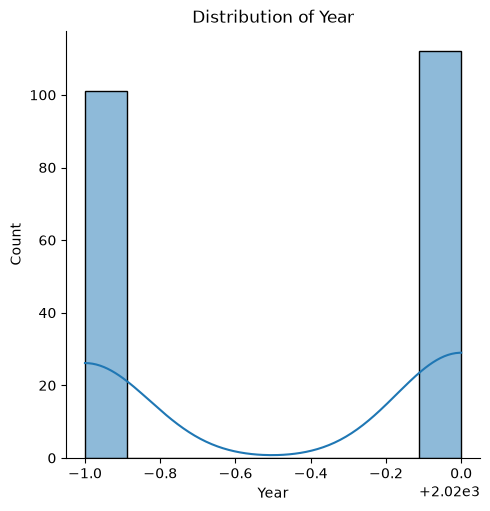

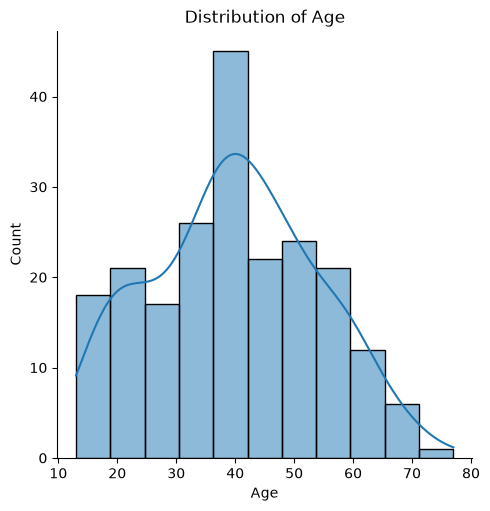

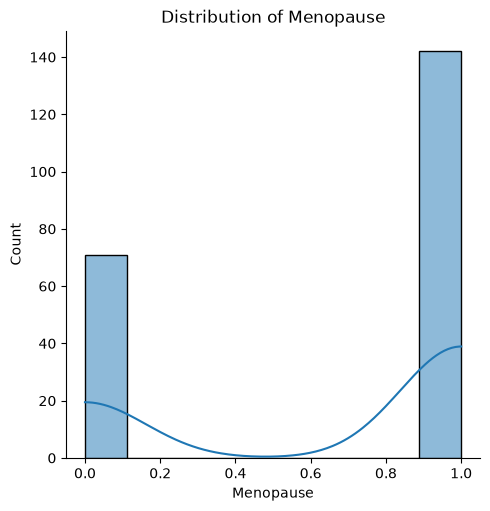

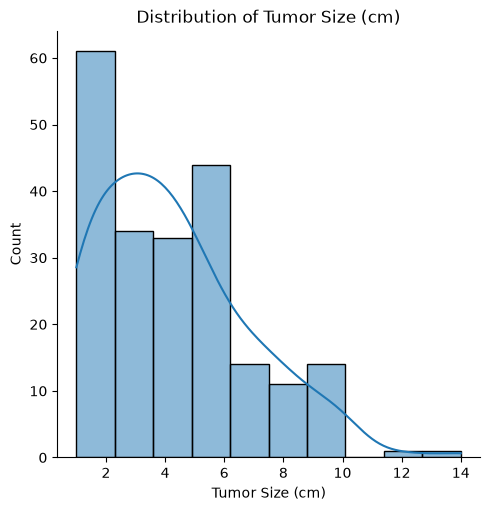

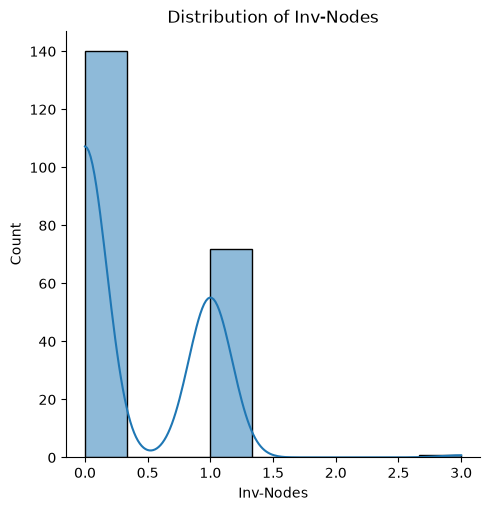

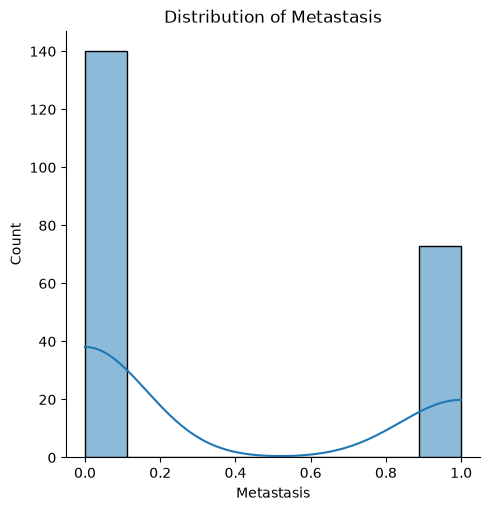

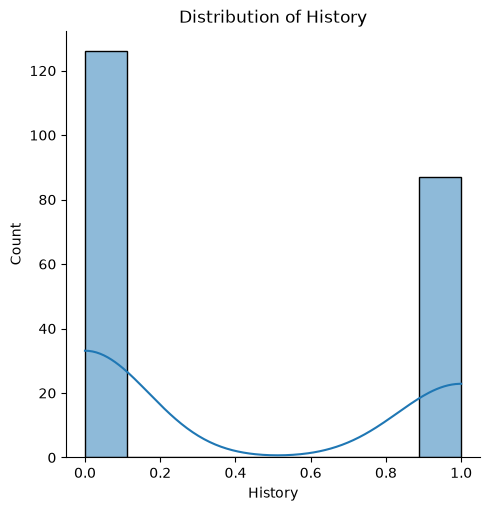

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Tumor Size (cm)",
    "Inv-Nodes",
    "Metastasis",
    "History"
]


for col in numerical_columns:
    sns.displot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [19]:
categorical_columns = [
    "Breast",
    "Breast Quadrant"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [20]:
df.isna().sum()

S/N                0
Year               0
Age                0
Menopause          0
Tumor Size (cm)    0
Inv-Nodes          0
Breast             0
Metastasis         0
Breast Quadrant    0
History            0
dtype: int64

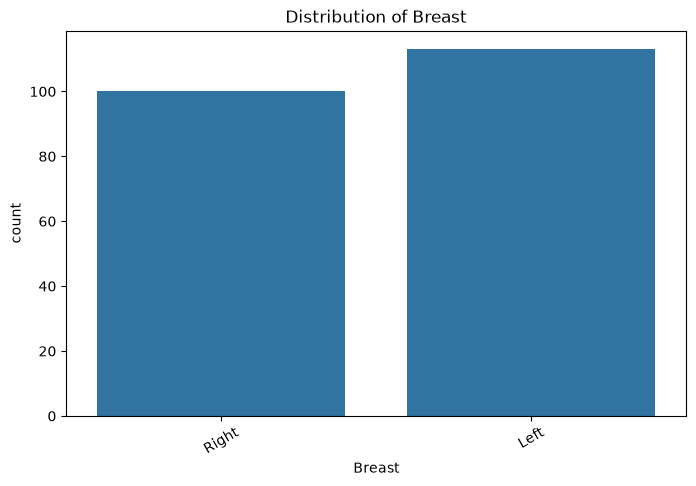

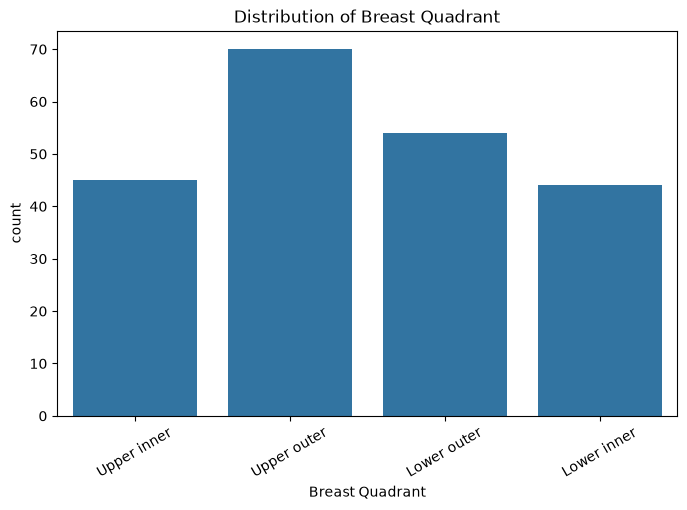

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_columns:
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x=col)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()

In [22]:
df[numerical_columns].skew()

Year              -0.104159
Age                0.076847
Menopause         -0.712132
Tumor Size (cm)    0.830511
Inv-Nodes          1.167320
Metastasis         0.667459
History            0.375141
dtype: float64

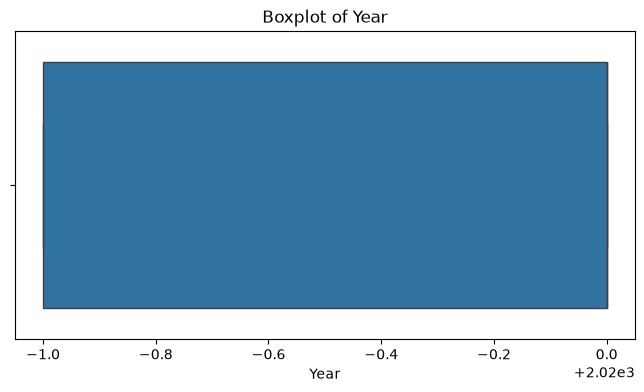

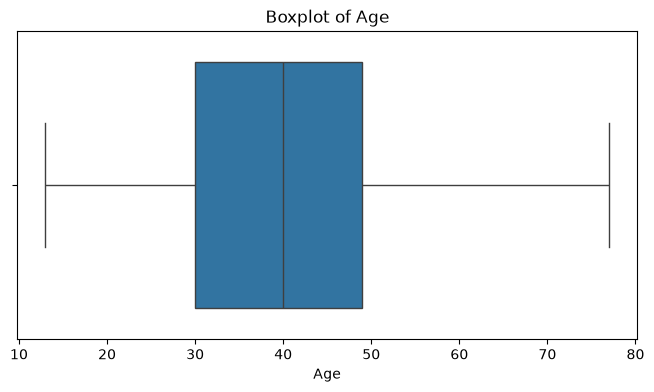

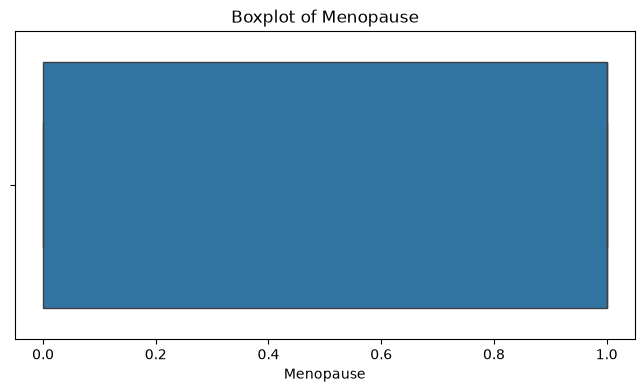

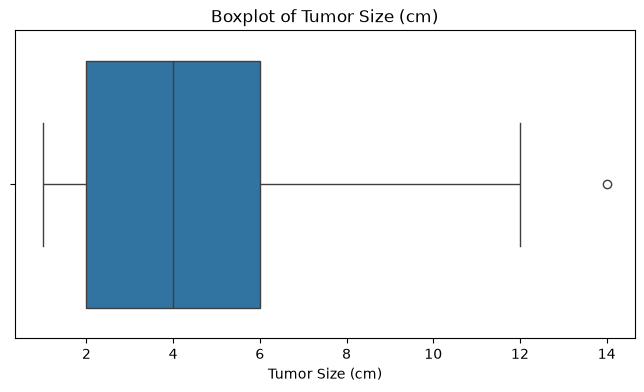

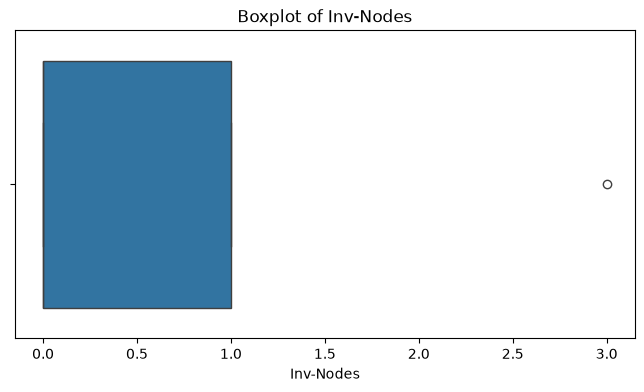

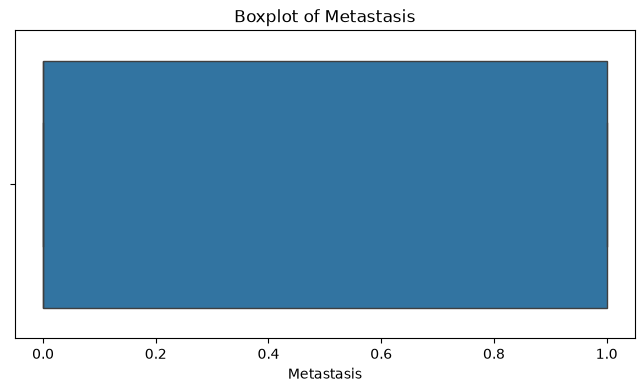

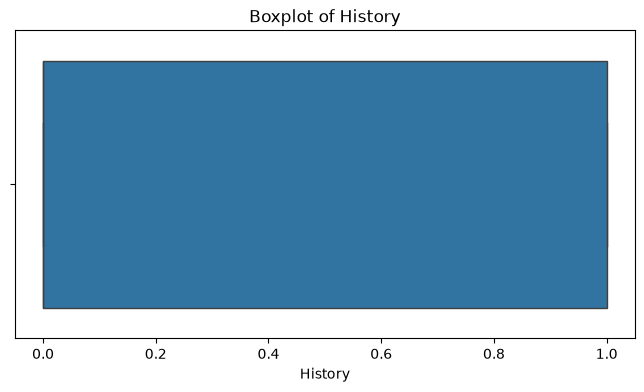

In [23]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

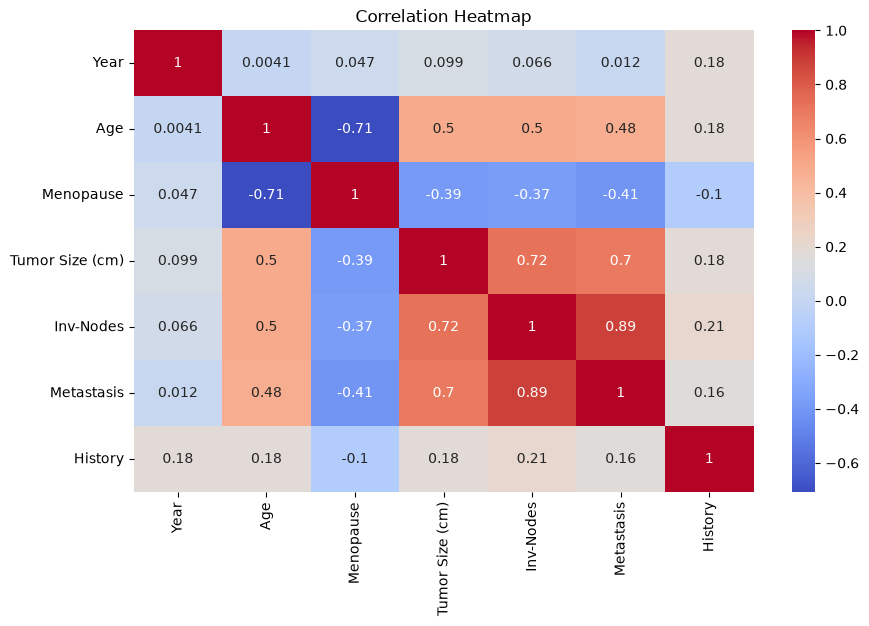

In [24]:
correlation = df[numerical_columns].corr()
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
df[numerical_columns].skew()

Year              -0.104159
Age                0.076847
Menopause         -0.712132
Tumor Size (cm)    0.830511
Inv-Nodes          1.167320
Metastasis         0.667459
History            0.375141
dtype: float64

In [26]:
df.head()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History
0,1,2019.0,40.0,1.0,2.0,0.0,Right,0.0,Upper inner,0.0
1,2,2019.0,39.0,1.0,2.0,0.0,Left,0.0,Upper outer,0.0
2,3,2019.0,45.0,0.0,4.0,0.0,Left,0.0,Lower outer,0.0
3,4,2019.0,26.0,1.0,3.0,0.0,Left,0.0,Lower inner,1.0
4,5,2019.0,21.0,1.0,1.0,0.0,Right,0.0,Upper outer,1.0


In [27]:
df = df.drop("S/N", axis=1)

In [28]:
numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Tumor Size (cm)",
    "Inv-Nodes",
    "Metastasis",
    "History"
]

transform_columns = [
    "Tumor Size (cm)"
]

non_transform_columns = [
    "Year",
    "Age",
    "Menopause",
    "Inv-Nodes",
    "Metastasis",
    "History"
]

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer #triggers columns and changes the value

trf1=ColumnTransformer([('impute_numerical',SimpleImputer(strategy="median"),["Tumor Size (cm)"])],remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas") #takes list inside tuple

In [30]:
df = trf1.fit_transform(df)
df.head()

,Tumor Size (cm),Year,Age,Menopause,Inv-Nodes,Breast,Metastasis,Breast Quadrant,History
0,2.0,2019.0,40.0,1.0,0.0,Right,0.0,Upper inner,0.0
1,2.0,2019.0,39.0,1.0,0.0,Left,0.0,Upper outer,0.0
2,4.0,2019.0,45.0,0.0,0.0,Left,0.0,Lower outer,0.0
3,3.0,2019.0,26.0,1.0,0.0,Left,0.0,Lower inner,1.0
4,1.0,2019.0,21.0,1.0,0.0,Right,0.0,Upper outer,1.0


In [31]:
from sklearn.preprocessing import PowerTransformer
trf2 = ColumnTransformer(
    [
        (
            "power_transform",
            PowerTransformer(method="yeo-johnson"),
            ["Tumor Size (cm)"]
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [32]:
df = trf2.fit_transform(df)
df.head()

,Tumor Size (cm),Year,Age,Menopause,Inv-Nodes,Breast,Metastasis,Breast Quadrant,History
0,-0.898526,2019.0,40.0,1.0,0.0,Right,0.0,Upper inner,0.0
1,-0.898526,2019.0,39.0,1.0,0.0,Left,0.0,Upper outer,0.0
2,0.102659,2019.0,45.0,0.0,0.0,Left,0.0,Lower outer,0.0
3,-0.343221,2019.0,26.0,1.0,0.0,Left,0.0,Lower inner,1.0
4,-1.645334,2019.0,21.0,1.0,0.0,Right,0.0,Upper outer,1.0


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

trf3 = ColumnTransformer(
    [
        (
            "scaling",
            StandardScaler(),
            ["Tumor Size (cm)"]
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [34]:
df = trf3.fit_transform(df)
df.head()

,Tumor Size (cm),Year,Age,Menopause,Inv-Nodes,Breast,Metastasis,Breast Quadrant,History
0,-0.898526,2019.0,40.0,1.0,0.0,Right,0.0,Upper inner,0.0
1,-0.898526,2019.0,39.0,1.0,0.0,Left,0.0,Upper outer,0.0
2,0.102659,2019.0,45.0,0.0,0.0,Left,0.0,Lower outer,0.0
3,-0.343221,2019.0,26.0,1.0,0.0,Left,0.0,Lower inner,1.0
4,-1.645334,2019.0,21.0,1.0,0.0,Right,0.0,Upper outer,1.0


In [35]:
print(df["Tumor Size (cm)"].mean())
print(df["Tumor Size (cm)"].std())

-1.2509555207044018e-17
1.0023557158674137


In [36]:
other_numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Inv-Nodes",
    "Metastasis",
    "History"
]

In [37]:
df[other_numerical_columns].isna().sum()

Year          0
Age           0
Menopause     0
Inv-Nodes     0
Metastasis    0
History       0
dtype: int64

In [38]:
from sklearn.preprocessing import StandardScaler

trf4 = ColumnTransformer(
    [
        (
            "scaling_numerical",
            StandardScaler(),
            other_numerical_columns
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [39]:
df = trf4.fit_transform(df)
df.head()

,Year,Age,Menopause,Inv-Nodes,Metastasis,History,Tumor Size (cm),Breast,Breast Quadrant
0,-1.053048,0.015356,0.707107,-0.695519,-0.7221,-0.830949,-0.898526,Right,Upper inner
1,-1.053048,-0.055749,0.707107,-0.695519,-0.7221,-0.830949,-0.898526,Left,Upper outer
2,-1.053048,0.370884,-1.414214,-0.695519,-0.7221,-0.830949,0.102659,Left,Lower outer
3,-1.053048,-0.980123,0.707107,-0.695519,-0.7221,1.203443,-0.343221,Left,Lower inner
4,-1.053048,-1.335651,0.707107,-0.695519,-0.7221,1.203443,-1.645334,Right,Upper outer


In [40]:
df[categorical_columns].isna().sum()

Breast             0
Breast Quadrant    0
dtype: int64

In [41]:
from sklearn.preprocessing import OneHotEncoder

trf5 = ColumnTransformer(
    [
        (
            "encode_categorical",
            OneHotEncoder(sparse_output=False),
            categorical_columns
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [42]:
df = trf5.fit_transform(df)
df.head()

,Breast_Left,Breast_Right,Breast Quadrant_Lower inner,Breast Quadrant_Lower outer,Breast Quadrant_Upper inner,Breast Quadrant_Upper outer,Year,Age,Menopause,Inv-Nodes,Metastasis,History,Tumor Size (cm)
0,0.0,1.0,0.0,0.0,1.0,0.0,-1.053048,0.015356,0.707107,-0.695519,-0.7221,-0.830949,-0.898526
1,1.0,0.0,0.0,0.0,0.0,1.0,-1.053048,-0.055749,0.707107,-0.695519,-0.7221,-0.830949,-0.898526
2,1.0,0.0,0.0,1.0,0.0,0.0,-1.053048,0.370884,-1.414214,-0.695519,-0.7221,-0.830949,0.102659
3,1.0,0.0,1.0,0.0,0.0,0.0,-1.053048,-0.980123,0.707107,-0.695519,-0.7221,1.203443,-0.343221
4,0.0,1.0,0.0,0.0,0.0,1.0,-1.053048,-1.335651,0.707107,-0.695519,-0.7221,1.203443,-1.645334


In [43]:
df.columns

Index(['Breast_Left', 'Breast_Right', 'Breast Quadrant_Lower inner',
       'Breast Quadrant_Lower outer', 'Breast Quadrant_Upper inner',
       'Breast Quadrant_Upper outer', 'Year', 'Age', 'Menopause', 'Inv-Nodes',
       'Metastasis', 'History', 'Tumor Size (cm)'],
      dtype='str')

In [46]:
numerical_transform_columns = [
    "Tumor Size (cm)"
]

other_numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Inv-Nodes",
    "Metastasis",
    "History"
]

categorical_columns = [
    "Breast",
    "Breast Quadrant"
]

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler

tumor_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

In [49]:
tumor_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto 

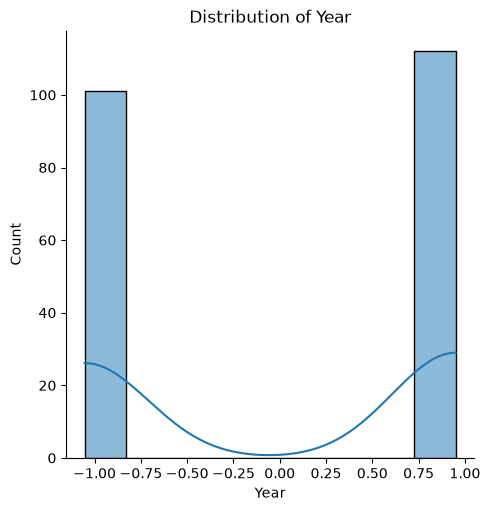

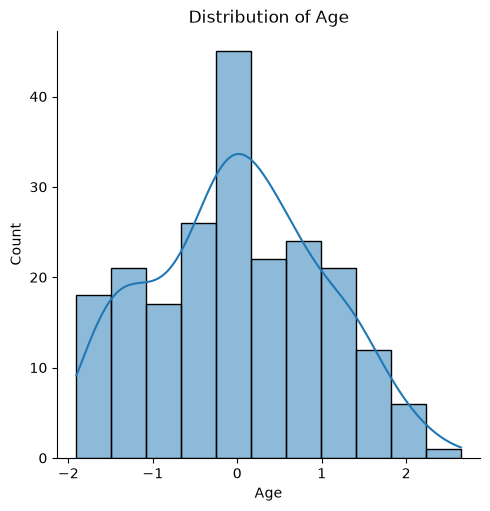

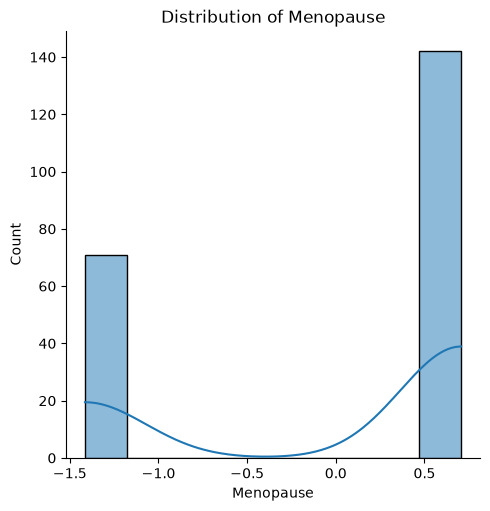

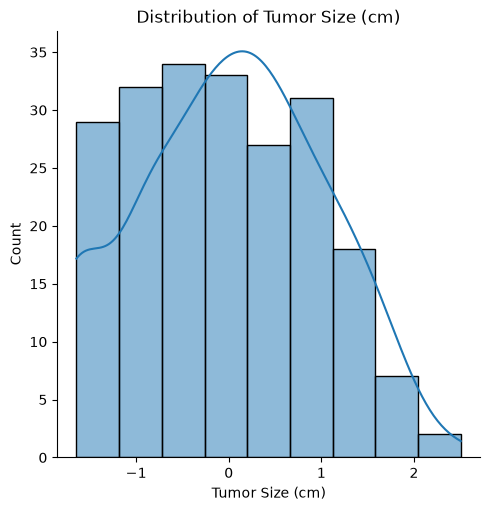

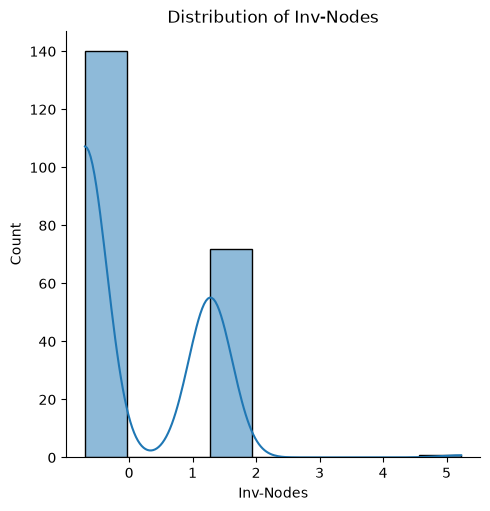

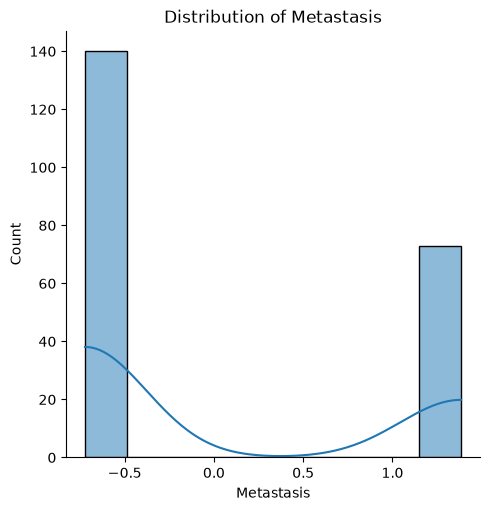

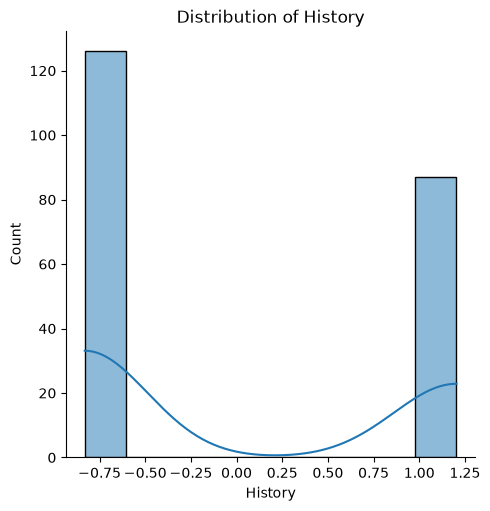

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = [
    "Year",
    "Age",
    "Menopause",
    "Tumor Size (cm)",
    "Inv-Nodes",
    "Metastasis",
    "History"
]


for col in numerical_columns:
    sns.displot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [45]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)


NameError: name 'preprocessor' is not defined